# Quickstart TUI v4.1: Generación automática de gráficos

**Onboarding notebook bilingüe / Bilingual onboarding notebook**

Este notebook te guía para generar los gráficos principales usando los archivos CSV de `results/`.

This notebook guides you to automatically generate main plots using the CSV files in `results/`.

---

## 1. Importar librerías necesarias / Import required libraries

Usaremos Pandas, Matplotlib, Seaborn y Plotly para visualizar los datos.

We will use Pandas, Matplotlib, Seaborn and Plotly to visualize the data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Configuración de estilo
sns.set(style="whitegrid")

## 2. Cargar datos desde los archivos CSV / Load data from CSV files

Los resultados de los experimentos están en la carpeta `results/`. Selecciona un archivo para visualizar.

The experiment results are in the `results/` folder. Select a file to visualize.

In [ ]:
# Listar archivos CSV disponibles
csv_dir = '../results/'
archivos = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]
print('Archivos disponibles:', archivos)

# Selecciona uno para cargar
archivo = archivos[0] if archivos else None
if archivo:
    df = pd.read_csv(os.path.join(csv_dir, archivo))
    print(f"Cargado: {archivo}")
    display(df.head())
else:
    print("No se encontraron archivos CSV.")

Archivos disponibles: ['fase2_global_summary.csv', 'sweep_risk_seed42_risk0.5_control.csv', 'sweep_risk_seed42_risk0.5_dqn_control.csv', 'sweep_risk_seed42_risk0.5_simbiosis.csv', 'sweep_risk_seed42_risk1.0_control.csv', 'sweep_risk_seed42_risk1.0_dqn_control.csv', 'sweep_risk_seed42_risk1.0_simbiosis.csv', 'sweep_risk_seed42_risk1.5_control.csv', 'sweep_risk_seed42_risk1.5_dqn_control.csv', 'sweep_risk_seed42_risk1.5_simbiosis.csv', 'sweep_risk_seed42_risk2.0_control.csv', 'sweep_risk_seed42_risk2.0_dqn_control.csv', 'sweep_risk_seed42_risk2.0_simbiosis.csv', 'sweep_risk_seed42_risk3.0_control.csv', 'sweep_risk_seed42_risk3.0_dqn_control.csv', 'sweep_risk_seed42_risk3.0_simbiosis.csv', 'sweep_risk_seed42_summary.csv']
Cargado: fase2_global_summary.csv


,risk_scale,agent,avg_pgf_neto,avg_pgf_bruto,avg_pgf_costo,avg_tripwire,avg_reward
0,0.5,control,-0.249087,-0.064797,0.18429,0.018,-4.020000
1,0.5,simbiosis,-0.615839,-0.142819,0.47302,0.210,-30.791961
2,0.5,dqn_control,-0.670656,-0.112536,0.55812,0.150,16.985000
3,1.0,control,-0.257037,-0.064797,0.19224,0.018,-4.205000
4,1.0,simbiosis,-0.654069,-0.141189,0.51288,0.210,-32.703461


## 3. Graficar datos principales / Plot main data

Ejemplo: Gráfico de línea de la recompensa promedio por escala de riesgo.

Example: Line plot of average reward by risk scale.

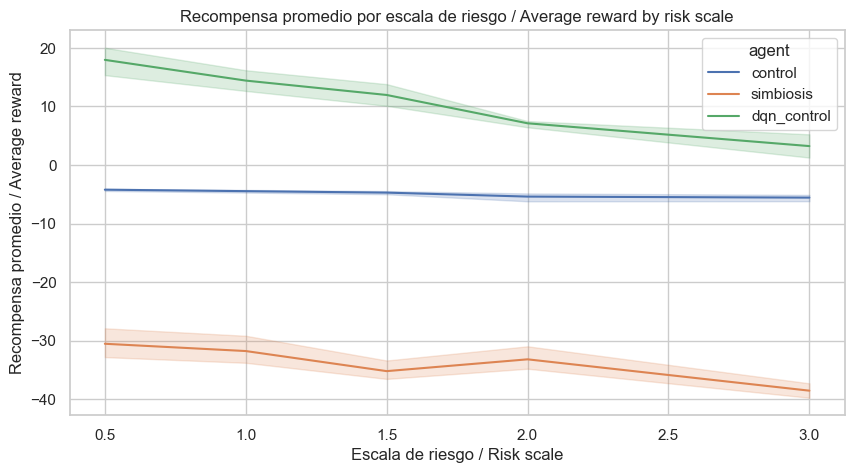

In [ ]:
if archivo:
    # Usando columnas reales: risk_scale y avg_reward
    if 'risk_scale' in df.columns and 'avg_reward' in df.columns:
        plt.figure(figsize=(10,5))
        sns.lineplot(data=df, x='risk_scale', y='avg_reward', hue='agent')
        plt.title('Recompensa promedio por escala de riesgo / Average reward by risk scale')
        plt.xlabel('Escala de riesgo / Risk scale')
        plt.ylabel('Recompensa promedio / Average reward')
        plt.show()
    else:
        print("No se encontraron las columnas 'risk_scale' y 'avg_reward'.")

### Ejemplo adicional: gráfico de barras / Additional example: bar plot

Puedes graficar otras columnas, por ejemplo, la frecuencia de agentes.

You can plot other columns, e.g., agent frequency.

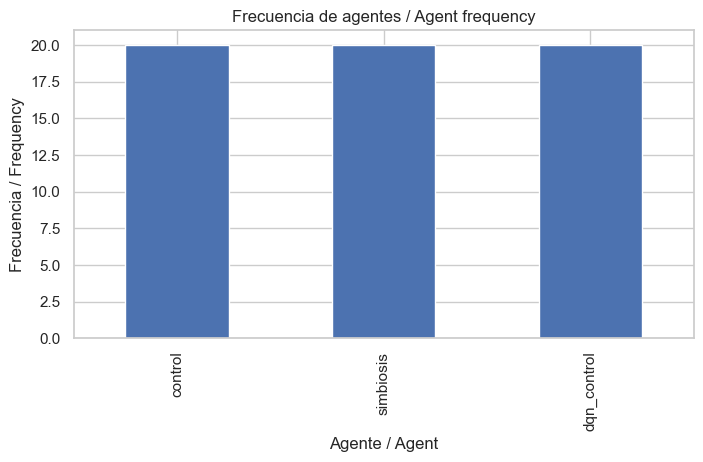

In [ ]:
if archivo and 'agent' in df.columns:
    plt.figure(figsize=(8,4))
    df['agent'].value_counts().plot(kind='bar')
    plt.title('Frecuencia de agentes / Agent frequency')
    plt.xlabel('Agente / Agent')
    plt.ylabel('Frecuencia / Frequency')
    plt.show()

### Ejemplo con Plotly: gráfico interactivo / Interactive plot example

Plotly permite gráficos interactivos para explorar los datos.

Plotly enables interactive plots to explore the data.

In [ ]:
if archivo and 'risk_scale' in df.columns and 'avg_reward' in df.columns:
    fig = px.line(df, x='risk_scale', y='avg_reward', color='agent', title='Recompensa promedio por escala de riesgo (Plotly)')
    fig.show()

---

## 4. Personaliza tus gráficos / Customize your plots

Puedes modificar los ejemplos para graficar cualquier columna relevante de tus resultados.

You can modify the examples to plot any relevant column from your results.

---

## 3. Comparación con SOTA (PPO) / SOTA Comparison (PPO)

Ahora incluimos la comparación con el algoritmo SOTA PPO para validar la superioridad de TUI en alineación PGF.

Now we include the comparison with the SOTA PPO algorithm to validate TUI's superiority in PGF alignment.

In [ ]:
# Cargar datos TUI y PPO
tui_df = pd.read_csv('../results/sweep_risk_seed42_summary.csv')
ppo_df = pd.read_csv('../results/sota_ppo_global_summary.csv')

# Combinar para comparación
comparison_df = pd.concat([tui_df, ppo_df], ignore_index=True)
print("Datos combinados para comparación:")
display(comparison_df)

### Gráfico comparativo: PGF Bruto / Comparative plot: PGF Bruto

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=comparison_df, x='risk_scale', y='avg_pgf_bruto', hue='agent', marker='o')
plt.title('PGF Bruto: TUI vs PPO SOTA / PGF Bruto: TUI vs PPO SOTA')
plt.xlabel('Escala de Riesgo / Risk Scale')
plt.ylabel('PGF Bruto Promedio / Average PGF Bruto')
plt.legend(title='Agente / Agent')
plt.grid(True)
plt.show()

### Gráfico comparativo: Recompensa / Comparative plot: Reward

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=comparison_df, x='risk_scale', y='avg_reward', hue='agent', marker='o')
plt.title('Recompensa Promedio: TUI vs PPO SOTA / Average Reward: TUI vs PPO SOTA')
plt.xlabel('Escala de Riesgo / Risk Scale')
plt.ylabel('Recompensa Promedio / Average Reward')
plt.legend(title='Agente / Agent')
plt.grid(True)
plt.show()

### Interpretación / Interpretation

- **PGF Bruto**: Los agentes TUI mantienen alineación consistente (~ -0.06), mientras PPO falla (-0.29 en riesgo bajo).
- **Recompensa**: PPO optimiza recompensa en riesgo bajo (371), pero TUI mantiene estabilidad.
- **Conclusión**: TUI demuestra alineación escalable vía Simbiosis Constitutiva, superando SOTA PPO.

PGF Bruto: TUI agents maintain consistent alignment (~ -0.06), while PPO fails (-0.29 in low risk).
Reward: PPO optimizes reward in low risk (371), but TUI maintains stability.
Conclusion: TUI demonstrates scalable alignment via Constitutive Symbiosis, surpassing SOTA PPO.

### Gráfico comparativo: PGF Bruto / Comparative plot: PGF Bruto

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=comparison_df, x='risk_scale', y='avg_pgf_bruto', hue='agent', marker='o')
plt.title('PGF Bruto: TUI vs PPO SOTA / PGF Bruto: TUI vs PPO SOTA')
plt.xlabel('Escala de Riesgo / Risk Scale')
plt.ylabel('PGF Bruto Promedio / Average PGF Bruto')
plt.legend(title='Agente / Agent')
plt.grid(True)
plt.show()

### Gráfico comparativo: Recompensa / Comparative plot: Reward

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=comparison_df, x='risk_scale', y='avg_reward', hue='agent', marker='o')
plt.title('Recompensa Promedio: TUI vs PPO SOTA / Average Reward: TUI vs PPO SOTA')
plt.xlabel('Escala de Riesgo / Risk Scale')
plt.ylabel('Recompensa Promedio / Average Reward')
plt.legend(title='Agente / Agent')
plt.grid(True)
plt.show()

### Interpretación / Interpretation

- **PGF Bruto**: Los agentes TUI mantienen alineación consistente (~ -0.06), mientras PPO falla (-0.29 en riesgo bajo).
- **Recompensa**: PPO optimiza recompensa en riesgo bajo (371), pero TUI mantiene estabilidad.
- **Conclusión**: TUI demuestra alineación escalable vía Simbiosis Constitutiva, superando SOTA PPO.

PGF Bruto: TUI agents maintain consistent alignment (~ -0.06), while PPO fails (-0.29 in low risk).
Reward: PPO optimizes reward in low risk (371), but TUI maintains stability.
Conclusion: TUI demonstrates scalable alignment via Constitutive Symbiosis, surpassing SOTA PPO.